# Forecasting Equity-Market Volatility

## Research Question

Can machine-learning models improve out-of-sample forecasts of
21-day realized volatility relative to persistence and classical
conditional-volatility models?

We compare:

- Naive volatility persistence
- HAR-style realized-volatility models
- GARCH
- Linear regression
- Support Vector Regression

## Forecast design

Forecasts are produced by an expanding-window walk-forward loop:

1. Each prediction uses only information available at its own date.
2. The model is fitted on historical observations only, with a 21-day
   embargo between the end of the training sample and the first test date.
3. The fitted model predicts the 21-day-ahead volatility for each of the
   next 21 trading days.
4. The forecast origin is advanced by 21 trading days and the model refitted.

Because the target overlaps from one day to the next, the headline
comparison uses only one forecast per block (non-overlapping origins).

The walk-forward period is split in two: an early **selection period**
(used for diagnostics and hyperparameter choice) and a later
**final test period**, which is never used to choose anything.

Note: you may need to restart the kernel to use updated packages.


ERROR: unknown command "insta" - maybe you meant "install"



In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import yfinance as yf

from arch import arch_model

from statsmodels.graphics.tsaplots import plot_acf

from sklearn.base import clone
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

## 1. Data

We use daily S&P 500 index prices. 

The forecasting target is the **annualized standard deviation of the next 21 daily returns**:

In [3]:
ticker = "^GSPC"

data = yf.download(ticker , start="2005-01-01", end="2024-01-01")
if isinstance(data.columns, pd.MultiIndex): 
    data.columns = data.columns.get_level_values(0)
    
df=data[["Close"]].copy()   #data[["Close"]] returns a DataFrame (2D table), whereas data["Close"] returns a Series (1D) 

[*********************100%***********************]  1 of 1 completed


### Simple Returns vs. Log Returns

In financial analysis and quantitative modeling, measuring asset price performance is done using either **simple returns** or **logarithmic (log) returns**.

For an asset price moving from $P_{t-1}$ to $P_t$:

* **Simple Return ($R_t$):**
  $$R_t = \frac{P_t - P_{t-1}}{P_{t-1}} = \frac{P_t}{P_{t-1}} - 1$$

* **Log Return ($r_t$):**
  $$r_t = \ln\left(\frac{P_t}{P_{t-1}}\right) = \ln(P_t) - \ln(P_{t-1})$$


We use log returns:

$$r_t = \log(P_t/P_{t-1})$$

Log returns are convenient for time-series modeling because they
are additive through time and are standard inputs for conditional
volatility models such as ARCH/GARCH.

Simple returns are asymmetric (a $-50\%$ loss requires a $+100\%$ gain to break even). Log returns are symmetrical:
* $\$100 \rightarrow \$200$: $\ln(200/100) = +0.6931$
* $\$200 \rightarrow \$100$: $\ln(100/200) = -0.6931$
* **Sum = 0**, correctly representing zero net value change.

(The simple returns are $+100\%$ and $-50\%$: it is the log returns, not the
percentage moves, that cancel out.)


#### Exploratory volatility diagnostics

In [4]:
DAYS_PER_YEAR = 252

df['Log Return'] = np.log(df['Close']).diff()


df['RV21']= df['Log Return'].rolling(window=21).std()*np.sqrt(DAYS_PER_YEAR)
df.dropna(inplace=True)

df['P/SMA_20']=df['Close']/df['Close'].rolling(window=20).mean()
df['P/SMA_50']=df['Close']/df['Close'].rolling(window=50).mean()
df.dropna(inplace=True)
df.head()

Price,Close,Log Return,RV21,P/SMA_20,P/SMA_50
Date,,,,,
2005-04-14,1162.050049,-0.010052,0.104131,0.985933,0.973520
2005-04-15,1142.619995,-0.016862,0.115032,0.971409,0.958054
2005-04-18,1145.979980,0.002936,0.115554,0.976078,0.961579
2005-04-19,1152.780029,0.005916,0.118561,0.983167,0.968102
2005-04-20,1137.500000,-0.013344,0.125029,0.971553,0.956301


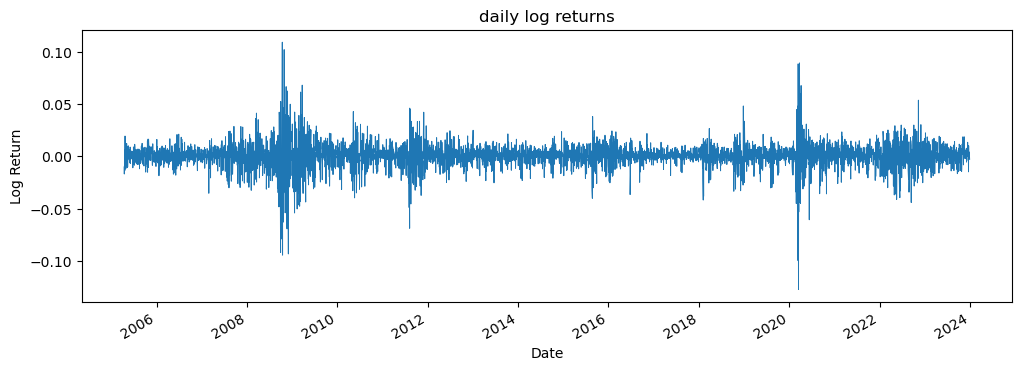

In [5]:
fig, ax = plt.subplots(figsize=(12,4))
df["Log Return"].plot(ax=ax, lw=0.7)
ax.set_title("daily log returns")
ax.set_ylabel("Log Return")
plt.show()

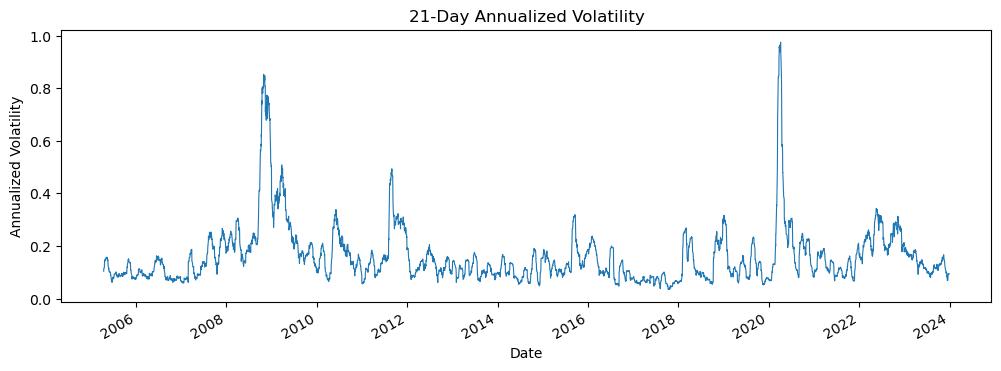

In [6]:
fig, ax = plt.subplots(figsize=(12,4))
df["RV21"].plot(ax=ax, lw=0.8)
ax.set_title("21-Day Annualized Volatility")
ax.set_ylabel("Annualized Volatility")
plt.show()

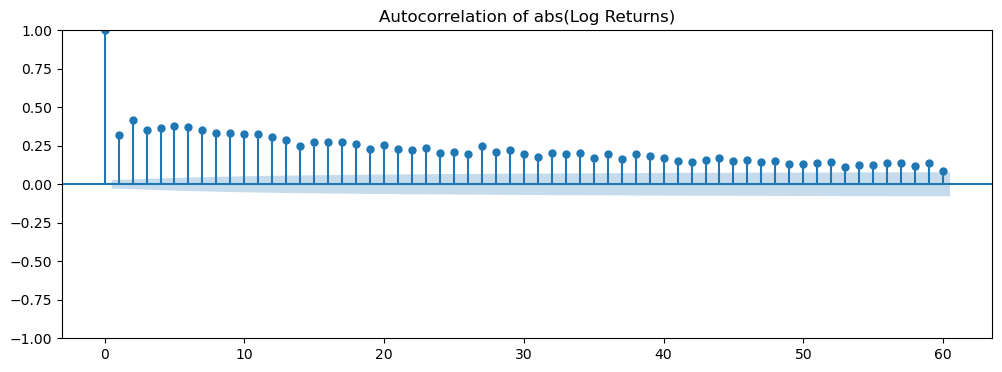

In [7]:
fig, ax = plt.subplots(figsize=(12,4))
plot_acf(df['Log Return'].abs(), lags=60, ax=ax)
ax.set_title("Autocorrelation of abs(Log Returns)")
plt.show()

While daily returns typically show little autocorrelation (today's return is a very bad indicator for tomorrow's return), their absolute values show significant positive autocorrelation, which decays slowly and stays visible over the whole 60-lag window.
This indicates that large price movements (in magnitude) tend to be followed by other large magnitudes, same for small magnitudes: **volatility clustering**

## Feature Engineering
We separate predictors into two groups:
### Volatility persistence
As seen in autocorrelation plots, prices volatility is persistent, high volatility periods tend to follow other high volatility periods. Therefore, lagged 21-day annualized realized volatility can be used as a predictor for the next 21-day volatility. 
- 21-day realized volatility.  
- LAG 1/5/21 of realized vol.

### Market state
- price / SMA20
- price / SMA50
- RSI (simple-moving-average variant, not Wilder's smoothing)

In [8]:
df['LAG1']=df['RV21'].shift(1)
df['LAG5']=df['RV21'].shift(5)
df['LAG21']=df['RV21'].shift(21)

def compute_rsi(df, price_col='Close', window=14):
    delta=df[price_col].diff()
    
    up_mean=(delta.where(delta>0, other=0)).rolling(window=window).mean()
    down_mean=-(delta.where(delta<0,other=0)).rolling(window=window).mean()
    
    rs = up_mean/down_mean
    
    return 100-100/(1+rs)

    
df['RSI14']=compute_rsi(df)
df.dropna(inplace=True)

In [9]:
# Target: annualized standard deviation of the NEXT 21 daily log returns.
# rolling(21).std() at date t+21 covers t+1 ... t+21, so shift(-21) attaches it to t:
# the target uses no information available at or before t.
# Note: this is the (demeaned) sample std, not the sqrt of the sum of squared returns
# sometimes used as the realized-volatility estimator. The difference is small here.
df["Target"] = (
    df["Log Return"]
    .rolling(21)
    .std()
    .shift(-21)
    * np.sqrt(252)
)

df.dropna(inplace=True)
df.head()

Price,Close,Log Return,RV21,P/SMA_20,P/SMA_50,LAG1,LAG5,LAG21,RSI14,Target
Date,,,,,,,,,,
2005-05-13,1154.050049,-0.004591,0.152742,0.995246,0.981630,0.155803,0.154138,0.104131,46.298888,0.077234
2005-05-16,1165.689941,0.010036,0.144242,1.004431,0.992484,0.152742,0.153465,0.115032,56.293128,0.071541
2005-05-17,1173.800049,0.006933,0.145593,1.010504,1.000266,0.144242,0.157848,0.115554,57.661874,0.069342
2005-05-18,1185.560059,0.009969,0.147925,1.018521,1.010871,0.145593,0.157256,0.118561,68.854683,0.063535
2005-05-19,1191.079956,0.004645,0.138242,1.021896,1.015854,0.147925,0.155803,0.125029,66.429877,0.062624


In [10]:
target=['Target']
features=['RV21', 'P/SMA_50', 'P/SMA_20', 'RSI14', 'LAG1', 'LAG5', 'LAG21']

# Everything before SPLIT is used for diagnostics and hyperparameter selection.
# Everything from SPLIT onwards is the final test period.
SPLIT = '2017-01-01'

In [11]:
df[features+target].corr()['Target'].sort_values(ascending=False)

Price
Target      1.000000
RV21        0.668994
LAG1        0.653984
LAG5        0.598970
LAG21       0.447264
RSI14      -0.300882
P/SMA_20   -0.416751
P/SMA_50   -0.510614
Name: Target, dtype: float64

# Baseline models

## Naive persistence baseline
A naive persistence model assumes that next 21-days volatility is equal to the past 21-days volatility. 
$$ RV_{t}^{(21)}=RV_{t+21}^{(21)} $$


In [12]:
# Naive persistence: the forecast of Target_t (vol over t+1..t+21) is RV21_t (vol over t-20..t).
# Kept as a full series; it is reindexed on the walk-forward dates when scoring,
# so that every model is evaluated on exactly the same dates.
naive_preds = df["RV21"]

## "HAR-RV style" model for realized volatility
A persistence baseline model for volatility predictions. Canonical **HAR-RV** assumes that tomorrow's variance $\sigma^2_{t+1}$ is a linear function of realized variance accross different horizons. In our project, however, rv_21 already represents 21-day realized volatility. We therefore use an adapted HAR-RV-style model to forecast the 21-day volatility target using volatility information from three different horizons (daily, weekly, monthly).
We will be assuming that: 

$$\boxed{RV_{t+21}^{(21)} = \alpha_0 +\alpha_1\sigma_t^{(1)} + \alpha_2\sigma_t^{(5)} + \alpha_3 RV_t^{(21)}}$$

Where we define : 

$$\sigma_t = \sqrt{252}\,|r_t| = \text{1-day annualized volatility} \quad \text{and} \quad \sigma^{(k)}_t=\dfrac{1}{k} \sum_{j=0}^{k-1} \sigma_{t-j}$$

The three components are computed at date $t$ and are therefore known at the
forecast origin. The monthly component is `RV21` itself (the most recent
21-day realized volatility), so the most recent information is not discarded.

## Walk-Forward Evaluation

For each block of 21 trading days starting at \(t\):

1. Train using observations available before \(t\), minus a 21-day embargo,
   so that no training target overlaps the test block.
2. Apply preprocessing using the training sample only.
3. Predict the 21-day-ahead volatility for each of the 21 days of the block.
4. Record the forecasts.
5. Advance the origin by 21 trading days.
6. Refit the model.

This prevents future observations from entering the training set: **data leakage**

The forecasts inside a block overlap each other, so the headline table keeps
only the first prediction of each block.
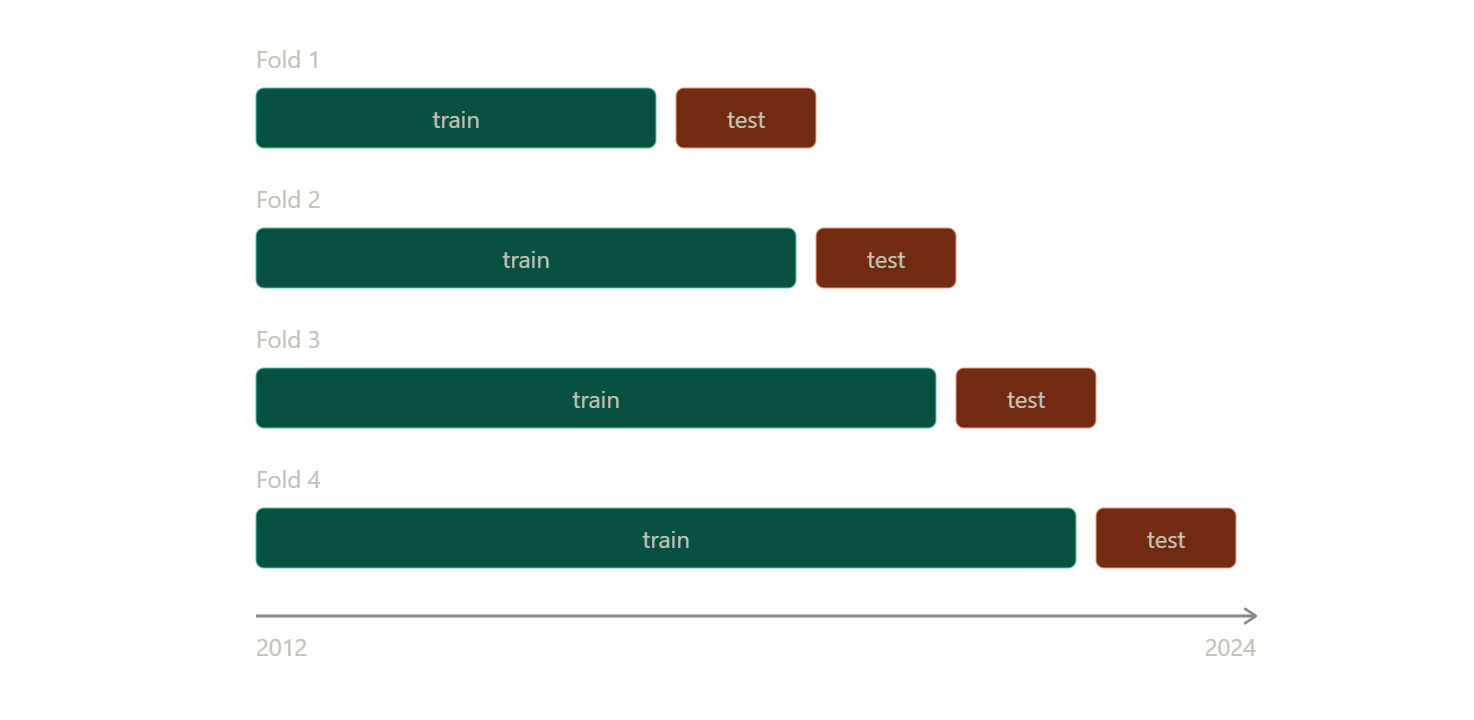


In [13]:
def walk_forward(df, features, target, model_fn, embargo=21, initial=1000, step=21, train_stride = 1):
    
    preds, actuals, dates=[],[],[]
    for start in range(initial, len(df)-step, step):
        train, test = df.iloc[:start-embargo], df.iloc[start:start+step]
        train = train.iloc[(len(train)-1)%train_stride :: train_stride]
        if start == initial:
            print(f"train rows: {len(train)}")
        scaler=StandardScaler()
        Xtrain, Xtest = scaler.fit_transform(train[features].values), scaler.transform(test[features].values)
        Ytrain, Ytest = train[target].values, test[target].values

        model=model_fn()
        model.fit(Xtrain, Ytrain.ravel())

        preds.append(model.predict(Xtest))
        actuals.append(Ytest.ravel())
        dates.append(test.index)
        
    return (pd.Series(np.concatenate(preds), index=dates[0].append(dates[1:])),
            pd.Series(np.concatenate(actuals), index=dates[0].append(dates[1:])))

In [14]:
# HAR-style components, all known at date t
df['SIGMA_D'] = df['Log Return'].abs() * np.sqrt(DAYS_PER_YEAR)
df['SIGMA_W'] = df['SIGMA_D'].rolling(5).mean()
df.dropna(inplace=True)

har_features = ['SIGMA_D', 'SIGMA_W', 'RV21']
har_preds, har_actuals = walk_forward(df, har_features, target, lambda: LinearRegression(), step=21)
df.head()

train rows: 979


Price,Close,Log Return,RV21,P/SMA_20,P/SMA_50,LAG1,LAG5,LAG21,RSI14,Target,SIGMA_D,SIGMA_W
Date,,,,,,,,,,,,
2005-05-19,1191.079956,0.004645,0.138242,1.021896,1.015854,0.147925,0.155803,0.125029,66.429877,0.062624,0.073739,0.114847
2005-05-20,1189.280029,-0.001512,0.123385,1.018728,1.014664,0.138242,0.152742,0.141474,63.471116,0.062922,0.024007,0.105074
2005-05-23,1193.859985,0.003844,0.120192,1.021262,1.018680,0.123385,0.144242,0.143048,65.678666,0.062079,0.061016,0.085415
2005-05-24,1194.069946,0.000176,0.117590,1.019600,1.019081,0.120192,0.145593,0.146750,60.235594,0.074132,0.002792,0.063961
2005-05-25,1190.010010,-0.003406,0.113069,1.014676,1.015750,0.117590,0.147925,0.149225,59.547391,0.078140,0.054067,0.043124


# Machine Learning models: Linear Regression and SVR 

In [15]:
# epsilon is in the units of the target (annualized vol, typically ~0.15),
# so it must be small compared with the forecast errors we are trying to fit.
lr_wf_preds, lr_wf_actuals = walk_forward(df, features, target, lambda: LinearRegression(), step=21)
svr_wf_preds, svr_wf_actuals = walk_forward(df, features, target, lambda: SVR(kernel='linear', C=1, epsilon=0.01), train_stride = 5)

train rows: 979
train rows: 196


In [16]:
def qlike(actuals, preds):
    """QLIKE loss. Inputs are volatilities; the loss is computed on variances,
    which is the form for which QLIKE is robust to a noisy volatility proxy."""
    v_pred = np.clip(np.asarray(preds, dtype=float)**2, 1e-18, None)
    v_act = np.clip(np.asarray(actuals, dtype=float)**2, 1e-18, None)

    return np.mean(v_act/v_pred - np.log(v_act/v_pred)-1)

In [17]:
# Diagnostics on the SELECTION period only: the final test period is untouched here.
sel = lr_wf_preds.index < SPLIT
print(sel.shape, har_preds.shape, len(df.index < SPLIT))
sel_actual = lr_wf_actuals[sel]

sel_models = {
    "Naive":             naive_preds.reindex(lr_wf_preds.index)[sel],
    "HAR-style":         har_preds[sel],
    "Linear Regression": lr_wf_preds[sel],
    "SVR":               svr_wf_preds[sel],
}

MLresults = pd.DataFrame([
    {
        "Model": name,
        "MSE":   mean_squared_error(sel_actual, pred),
        "RMSE":  np.sqrt(mean_squared_error(sel_actual, pred)),
        "R²":    r2_score(sel_actual, pred),
        "QLIKE": qlike(sel_actual, pred),
    }
    for name, pred in sel_models.items()
]).set_index('Model').sort_values('QLIKE')   # lower QLIKE = better

MLresults

(3654,) (3654,) 4665


,MSE,RMSE,R²,QLIKE
Model,,,,
Linear Regression,0.003777,0.061458,0.167257,0.323961
HAR-style,0.003805,0.061681,0.161198,0.332628
SVR,0.003451,0.058744,0.239189,0.367638
Naive,0.004602,0.067842,-0.014716,0.535564


### SVR Hyperparameters

SVR performance is sensitive to \(C\), \(\epsilon\), and \(\gamma\).
Each configuration is scored on the **selection period only**
(walk-forward forecasts before `SPLIT`); the final test period is never
used to choose a configuration.

#### SVR with different configs: 

In [18]:
configs = {
    "OLS" : lambda: LinearRegression(),
    "SVR lin C=1" : lambda: SVR(kernel="linear", C=1, epsilon=0.01),
    "SVR lin C=10": lambda: SVR(kernel="linear", C=10, epsilon=0.01),
    "SVR rbf C=1, g=scale" : lambda : SVR(kernel="rbf", C=1, epsilon=0.01, gamma='scale', cache_size = 1000)} 

scores = []
config_preds = {}

for model_name, model_fn in configs.items(): 
    preds, actuals = walk_forward(df, features, target, model_fn, train_stride = 5)
    config_preds[model_name] = preds
    m = preds.index < SPLIT                      # selection period only
    scores.append({'Model': model_name,
                   'QLIKE': qlike(actuals[m], preds[m]),
                   'MSE': mean_squared_error(actuals[m], preds[m]),
                   'R2': r2_score(actuals[m], preds[m])})


train rows: 196
train rows: 196
train rows: 196
train rows: 196


In [19]:
MLresults=pd.DataFrame(scores).set_index('Model').sort_values('QLIKE')  

best_name = MLresults.index[0]
svr_best_preds = config_preds[best_name]
print("Selected on the selection period:", best_name)
MLresults

Selected on the selection period: OLS


,QLIKE,MSE,R2
Model,,,
OLS,0.333006,0.003846,0.152091
SVR lin C=10,0.362047,0.003441,0.241324
SVR lin C=1,0.367638,0.003451,0.239189
"SVR rbf C=1, g=scale",0.385991,0.004538,-0.000418


# Classic Volatility Models

Financial returns exhibit volatility clustering, motivating models
with time-varying conditional variance.

We use GARCH as a classical benchmark against which the ML models
are evaluated.

## 2. Mathematical Framework
We define returns $r_t$ as:
$$r_t = \mu_t + \epsilon_t$$ 

Where:
* $\mu_t$ is the expected return.
* $\epsilon_t = \sigma_t z_t$ is the residual error.
* $z_t \sim \mathcal{N}(0, 1)$ is an i.i.d. random noise process.
* $\sigma_t^2$ is the **conditional variance** at time $t$.

### 3. ARCH(q) Model
the **ARCH(q)** model specifies that today's variance depends on the magnitude of $q$ past squared shocks:

$$\sigma_t^2 = \omega + \sum_{i=1}^{q} \alpha_i \epsilon_{t-i}^2$$

#### ARCH(1):
$$\sigma_t^2 = \omega + \alpha_1 \epsilon_{t-1}^2$$

* $\omega > 0$: Baseline constant variance.
* $\alpha_1 \ge 0$: Reaction weight to yesterday's shock ($\epsilon_{t-1}^2$).

### 4. GARCH(p, q) Model
Introduced by Tim Bollerslev (1986), **GARCH(p, q)** adds lagged conditional variances ($\sigma^2$) to capture persistent volatility with fewer parameters than a high-order ARCH (the autocorrelation it implies still decays geometrically, so it is not a long-memory model):

$$\sigma_t^2 = \omega + \sum_{i=1}^{q} \alpha_i \epsilon_{t-i}^2 + \sum_{j=1}^{p} \beta_j \sigma_{t-j}^2$$

#### GARCH(1, 1) Specification:
$$\sigma_t^2 = \omega + \alpha_1 \epsilon_{t-1}^2 + \beta_1 \sigma_{t-1}^2$$

* $\alpha_1$ (**ARCH term**): Immediate reaction to yesterday's market shock.
* $\beta_1$ (**GARCH term**): Persistence of past volatility over time.
* **Stationarity Condition:** $\alpha_1 + \beta_1 < 1$. If $\alpha_1 + \beta_1 = 1$ (IGARCH) the unconditional variance is no longer finite, and shocks never die out.

#### Arch(p): Basic implementation, manually, then using **arch** library

In [20]:
#Basic arch model, alternative to using arch library
from scipy.optimize import minimize

def arch_log_likelihood(params,y,p=1):
    if len(params)!=p+1: 
        raise Exception("number of parameters dont match with p")

    omega=params[0]
    alphas=params[1:]
    if omega<=0 or any(a<0 for a in alphas) or sum(alphas)>=1:
        return 1e10
    T=len(y)
    s2=np.empty(T)
    s2[0]=y.var()
    for t in range(1,T):
        s2[t]=params[0] +sum([params[i]*y[t-i]**2 for i in range(1,len(params)) if t-i>=0])
    nll= np.sum(np.log(s2+ 1e-20)+y**2/(s2+ 1e-20))  #negative log-likelihood, constants are removed. 
    return nll


def arch_forecast(y, p=1, horizon=1):
    forecasts=np.empty(horizon)
    bounds = [(1e-8, None)] + [(0.0, 0.999)]*p
    opt=minimize(arch_log_likelihood, [0.1]*(p+1), args=(y,p,), method="L-BFGS-B", bounds=bounds)
    if not opt.success:
        raise RuntimeError(opt.message)
        
    params=opt.x  
    T=len(y)
    forecasts[0]=params[0]+sum([params[j]*y[T-j]**2 for j in range(1,len(params))])
    for i in range(1,horizon):
        forecasts[i]=params[0]+sum([params[j]*forecasts[i-j] if i-j>=0 else params[j]*y[T+i-j]**2 for j in range(1,len(params))])
    return forecasts
    

In [21]:
p=1 #p parameter in ARCH(p)
horizon=8 #number of predictions

In [22]:
#ARCH(p) Manual Model Implementation
log_r=100*df['Log Return'].dropna()
manual_arch_preds = arch_forecast(log_r.values, p=p, horizon=horizon)
manual_arch_preds

array([0.91237799, 1.32666473, 1.5166476 , 1.6037696 , 1.64372185,
       1.66204309, 1.6704448 , 1.67429765])

### Implementation using arch library. 

In [23]:
from arch import arch_model
library_arch_preds=arch_model(log_r, mean='Zero', vol="ARCH", p=p).fit(disp='off').forecast(horizon=horizon, reindex=False).variance.values[0]
library_arch_preds

array([0.91214285, 1.3263942 , 1.51639407, 1.60353912, 1.64350893,
       1.66184142, 1.67024977, 1.67410633])

In [24]:
manual_vs_library = pd.DataFrame({"manual_pred": manual_arch_preds, 
                                  "library_pred": library_arch_preds,
                                "relative error (%)": 100*np.abs(manual_arch_preds-library_arch_preds)/library_arch_preds})
manual_vs_library

,manual_pred,library_pred,relative error (%)
0,0.912378,0.912143,0.025780
1,1.326665,1.326394,0.020396
2,1.516648,1.516394,0.016719
3,1.603770,1.603539,0.014373
4,1.643722,1.643509,0.012955
5,1.662043,1.661841,0.012135
6,1.670445,1.670250,0.011677
7,1.674298,1.674106,0.011428


### GARCH(p,q) manual implementation

In [33]:
def garch_log_likelihood(params,y,p=1,q=1):
    """ Given params=(omega,alphas,betas), this functions returns the negative log likelihood of observations y, where
    we assume that each y[t] follow a centered normal distribution with variance s2[t]""" 
    
    if len(params)!=p+q+1: 
        raise Exception("number of initial parameters dont match with p and q")
        
    omega=params[0]
    alphas=params[1:p+1]
    betas=params[p+1:]
    #Heavy penalization if params contraints are not matched.
    if any(a<0 for a in params) or sum(alphas)+sum(betas)>=1:
        return 1e10
        
    s2=variance_path(params, y,p,q)
    nll= 0.5 * np.sum(np.log(2*np.pi*s2) + y**2/s2)  #negative log-likelihood, constants are removed. 
    return nll

def variance_path(params,y,p=1,q=1):
    """ Returns s2 time series """
    if p == 1 and q == 1:
        omega, alpha, beta = params
        T = len(y)
        s2 = np.empty(T)
        s2[0] = y.var()
        y2 = y**2
        for t in range(1, T):
            s2[t] = omega + alpha*y2[t-1] + beta*s2[t-1]
        return s2
    omega = params[0]
    alphas = params[1:p+1]
    betas = params[p+1:]

    T=len(y)
    s2=np.empty(T)
    s2[0]=y.var()
    for t in range(1,T):
        arch_term = sum([alphas[i]*y[t-i-1]**2 for i in range(p) if t-i-1>=0])
        garch_term = sum([betas[i]*s2[t-i-1] for i in range(q) if t-i-1>=0])
        s2[t]=params[0] + arch_term + garch_term
    return s2
    
def garch_fit(y, p=1, q=1):
    """fits the garch model, returns params and s2 time series.

    The likelihood has a hard penalty wall at sum(alpha)+sum(beta)=1, and the optimum
    for equity returns sits very close to it, so a single L-BFGS-B run from a fixed
    starting point sometimes stops at a clearly worse local solution while still
    reporting success. We therefore try several starting points and keep the best
    likelihood."""

    bounds = [(1e-8, None)] + [(0.0, 0.999)]*(p+q)
    var = y.var()

    starts = []
    for a_tot, b_tot in [(0.10, 0.85), (0.05, 0.90), (0.20, 0.70), (0.30, 0.50)]:
        omega0 = max(var*(1 - a_tot - b_tot), 1e-6)
        starts.append([omega0] + [a_tot/p]*p + [b_tot/q]*q)
    starts.append([0.1]*(p+q+1))

    best = None
    for x0 in starts:
        opt = minimize(garch_log_likelihood, x0, args=(y, p, q), method="L-BFGS-B", bounds=bounds)
        if opt.success and (best is None or opt.fun < best.fun):
            best = opt

    if best is None:
        raise RuntimeError("GARCH optimization fail")
        
    return best.x, variance_path(best.x, y, p, q)


def garch_forecast(params, y, s2, p=1, q=1, horizon=1):
    """predicts future variances for horizon next days using the previously trained garch model"""
    
    omega  = params[0]
    alphas = params[1:p+1]
    betas  = params[p+1:]
    T=len(y)
    forecasts=np.empty(horizon)
    for d in range(horizon):
        arch_term = sum([alphas[i]*(forecasts[d-i-1] if d-i-1>=0 else y[T+d-i-1]**2) for i in range(p)])
        garch_term = sum([betas[i]*(forecasts[d-i-1] if d-i-1>=0 else s2[T+d-i-1]) for i in range(q)])
        forecasts[d] = omega + arch_term + garch_term
    return forecasts
    

In [34]:
''' p and q values for GARCH(p,q) model, valid for both manual and library-based implementation'''
p,q=1,1

In [35]:
log_r=100*df['Log Return'].dropna().values

params, s2 = garch_fit(log_r,p,q)

manual_garch_preds = garch_forecast(params, log_r, s2, p=p,q=q, horizon=5)
manual_garch_preds

array([0.43599033, 0.45317882, 0.47001919, 0.48651849, 0.50268362])

#### GARCH(p,q) implementation using **arch** library.

In [36]:
from arch import arch_model
res = arch_model(log_r, mean='Zero', vol='GARCH', p=p, q=q, rescale=False).fit(disp='off')
library_garch_preds = res.forecast(horizon=5, reindex=False).variance.values[0]
library_garch_preds

array([0.44235415, 0.45880776, 0.47493593, 0.49074511, 0.50624158])

In [37]:
manual_vs_library = pd.DataFrame({"manual_pred": manual_garch_preds, 
                                  "library_pred": library_garch_preds,
                                "relative error (%)": 100*np.abs(manual_garch_preds-library_garch_preds)/library_garch_preds})

print("manual  NLL:", round(garch_log_likelihood(params, log_r, p, q), 4))
print("library NLL:", round(garch_log_likelihood(res.params.values, log_r, p, q), 4))
manual_vs_library

manual  NLL: 6290.168
library NLL: 6290.2223


,manual_pred,library_pred,relative error (%)
0,0.435990,0.442354,1.438624
1,0.453179,0.458808,1.226862
2,0.470019,0.474936,1.035243
3,0.486518,0.490745,0.861265
4,0.502684,0.506242,0.702819


### ARCH and GARCH backtesting

In [38]:
def garch_walk_forward(returns, vols, initial=1000, step=21, p=1, q=1):
    """Same origins as walk_forward: at origin `start`, the model is fitted on
    returns[:start+1] (the return of day `start` is known at the forecast origin,
    exactly as RV21 is for the ML models), and forecasts days start+1 ... start+21,
    which is the window covered by vols[start+21] = Target at `start`."""
    preds, actuals = [], []
    for start in range(initial, len(returns) - step, step):
        train = returns[:start+1]
        if start%100==0:
            print(start)
        params, s2 = garch_fit(train, p, q)
        fc = garch_forecast(params, train, s2, p=p, q=q, horizon=step)

        forecast_vol = np.sqrt(fc.sum()) * np.sqrt(252 / 21)/100

        actual_vol = vols[start + 21]
        
        preds.append(forecast_vol)
        actuals.append(actual_vol)
    return np.array(actuals), np.array(preds)

In [40]:
log_r = 100*df['Log Return'].dropna().values
garch_actuals, garch_preds = garch_walk_forward(log_r, df['RV21'].values)

1000
3100


# Metrics 
Different metrics are used to compare ML and classic volatility models, they can be separated into two interpretable families:
### Classic performance metrics: actuals vs. preds: 
- **QLIKE**: primary metric, widely used to compare volatility prediction. Compared to $R^2$, QLIKE is less dominated by the scale of the observations.
  It is defined on **variances**, which is the form under which it is robust to the fact that realized volatility is only a noisy proxy.
  If at time $t$ the realized 21-day variance is $RV_t^2$ and the predicted variance is $\hat\sigma^2_t$,
  $$ QLIKE_t = \dfrac{RV_t^2}{\hat\sigma^2_t} - \log\left(\dfrac{RV_t^2}{\hat\sigma^2_t}\right) -1$$
  $$ QLIKE = mean({QLIKE_t}) $$
  Lower is better.
- **R2** and **Corr**
  a zero **R^2** score means that the model does no better than a naive model where predicted values are equal to the mean of observed values.
  
  ### Performance relatively to baseline models:
- R2_vs_naive: $$R^2_{vs.Naive} = 1 - \frac{\operatorname{MSE}(\text{actuals},\text{model predictions})}
{\operatorname{MSE}(\text{actuals},\text{naive predictions})}$$
- R2_vs_HAR : $$R^2_{vs.HAR} = 1 - \frac{\operatorname{MSE}(\text{actuals},\text{model predictions})}
{\operatorname{MSE}(\text{actuals},\text{HAR predictions})}$$

For both relative (R^2) measures, a positive value means that the model has a lower MSE than the corresponding benchmark.

All the numbers below are computed on the **final test period** (from `SPLIT` onwards),
on non-overlapping 21-day origins.

In [42]:
# align: take the first prediction of each 21-day block
all_origins = lr_wf_preds.index[::21]

# GARCH uses the same origins as walk_forward
garch_all = pd.Series(garch_preds, index=all_origins)

# final test period only
origins = all_origins[all_origins >= SPLIT]
actual = df['Target'].reindex(origins)

models = {
    'OLS':            lr_wf_preds.reindex(origins),
    'SVR (selected)': svr_best_preds.reindex(origins),
    'HAR-style':      har_preds.reindex(origins),
    'GARCH(1,1)':     garch_all.reindex(origins),
    'Naive':          df['RV21'].reindex(origins),
}

sse_naive = ((actual - models['Naive'])**2).sum()
sse_har   = ((actual - models['HAR-style'])**2).sum()

rows = []
for name, pred in models.items():
    e = actual - pred.values
    rows.append({
        'Model':       name,
        'QLIKE':  qlike(actual, pred),
        'RMSE':        np.sqrt((e**2).mean()),
        'R2':          r2_score(actual, pred),
        'R2_vs_naive': 1 - (e**2).sum() / sse_naive,
        'R2_vs_HAR':   1 - (e**2).sum() / sse_har,
        'Corr':        np.corrcoef(actual, pred)[0, 1],
    })

results = pd.DataFrame(rows).set_index('Model').sort_values('QLIKE')
print(results.round(4))
print(f"\n{len(origins)} non-overlapping 21-day forecasts, "
      f"{origins[0].date()} → {origins[-1].date()}")

                 QLIKE    RMSE      R2  R2_vs_naive  R2_vs_HAR    Corr
Model                                                                 
GARCH(1,1)      0.6607  0.1044  0.1409      -0.0148    -0.0968  0.5863
HAR-style       0.7535  0.0997  0.2167       0.0748     0.0000  0.5919
OLS             0.8223  0.0962  0.2707       0.1385     0.0689  0.5982
Naive           0.8514  0.1036  0.1534       0.0000    -0.0808  0.5784
SVR (selected)  0.8613  0.0956  0.2792       0.1486     0.0798  0.5961

82 non-overlapping 21-day forecasts, 2017-01-11 → 2023-10-16


### Is the difference significant?

With fewer than a hundred non-overlapping forecasts, a lower QLIKE is not
by itself evidence that a model is better. The Diebold-Mariano test compares
the per-period losses of two models and tests whether their mean difference
is zero (negative statistic = the first model has the lower loss).

In [43]:
from scipy import stats

def qlike_losses(actuals, preds):
    v_p = np.clip(np.asarray(preds, dtype=float)**2, 1e-18, None)
    v_a = np.clip(np.asarray(actuals, dtype=float)**2, 1e-18, None)
    return v_a/v_p - np.log(v_a/v_p) - 1

def diebold_mariano(actuals, pred1, pred2):
    d = qlike_losses(actuals, pred1) - qlike_losses(actuals, pred2)
    n = len(d)
    stat = d.mean() / np.sqrt(d.var(ddof=1)/n)
    return stat, 2*(1 - stats.t.cdf(abs(stat), df=n-1))

best = results.index[0]
for name in results.index[1:]:
    stat, p = diebold_mariano(actual, models[best], models[name])
    print(f"{best} vs {name:<15} DM = {stat:6.2f}   p = {p:.3f}")

GARCH(1,1) vs HAR-style       DM =  -1.13   p = 0.264
GARCH(1,1) vs OLS             DM =  -0.99   p = 0.326
GARCH(1,1) vs Naive           DM =  -1.65   p = 0.104
GARCH(1,1) vs SVR (selected)  DM =  -1.01   p = 0.316


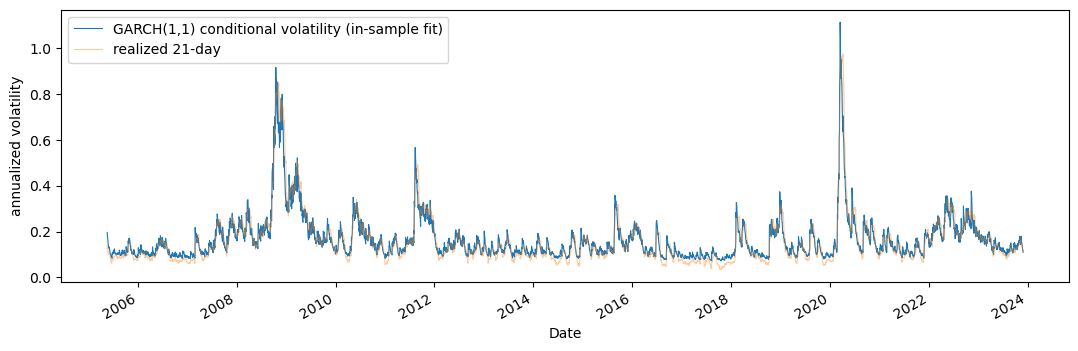

In [44]:
log_r = 100 * df['Log Return'].values
params, s2 = garch_fit(log_r, 1, 1)

cond_vol = pd.Series(np.sqrt(s2)/100*np.sqrt(252), index=df.index)

ax = cond_vol.plot(figsize=(13,4), lw=0.8, label='GARCH(1,1) conditional volatility (in-sample fit)')
df['RV21'].plot(ax=ax, alpha=0.4, lw=0.8, label='realized 21-day')
ax.set_ylabel('annualized volatility')
ax.legend()

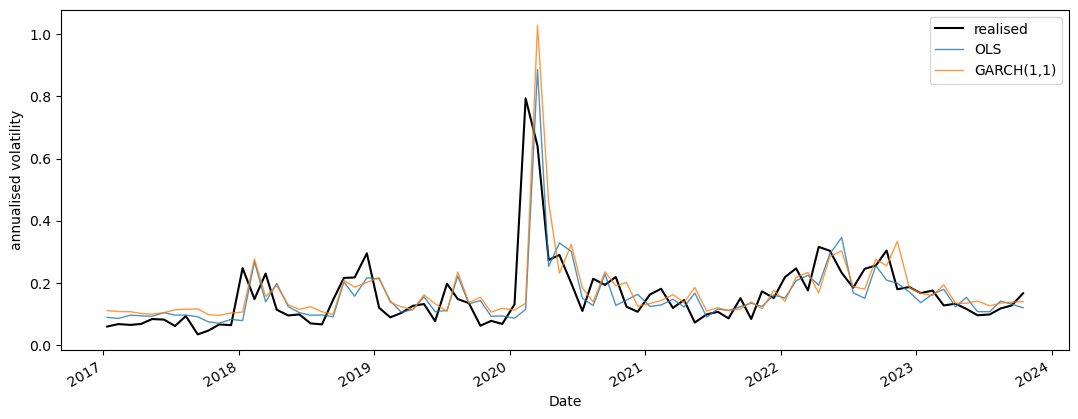

In [45]:
fig, ax = plt.subplots(figsize=(13, 5))
actual.plot(ax=ax, color='black', lw=1.5, label='realised')
for name in ['OLS', 'GARCH(1,1)']:
    models[name].plot(ax=ax, lw=1, alpha=0.8, label=name)
ax.set_ylabel('annualised volatility'); ax.legend()

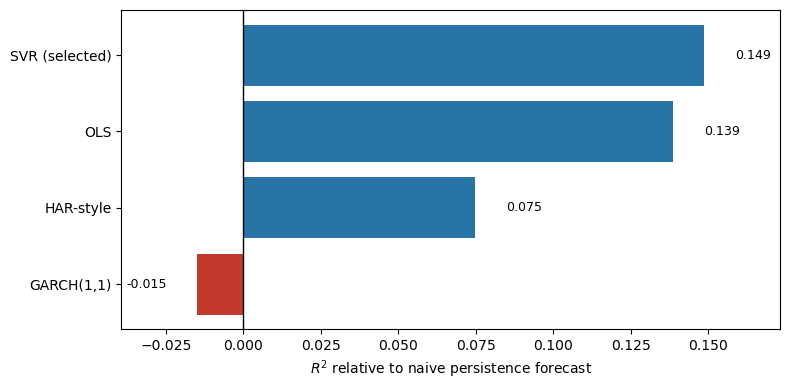

In [46]:
s = results['R2_vs_naive'].drop('Naive').sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(s.index, s.values,
        color=['#c0392b' if v < 0 else '#2874a6' for v in s.values])
ax.axvline(0, color='black', lw=1)

ax.set_xlabel('$R^2$ relative to naive persistence forecast')

for i, v in enumerate(s.values):
    ax.text(v + (0.01 if v >= 0 else -0.01), i, f'{v:.3f}',
            va='center', ha='left' if v >= 0 else 'right', fontsize=9)

ax.margins(x=0.15)
plt.tight_layout()

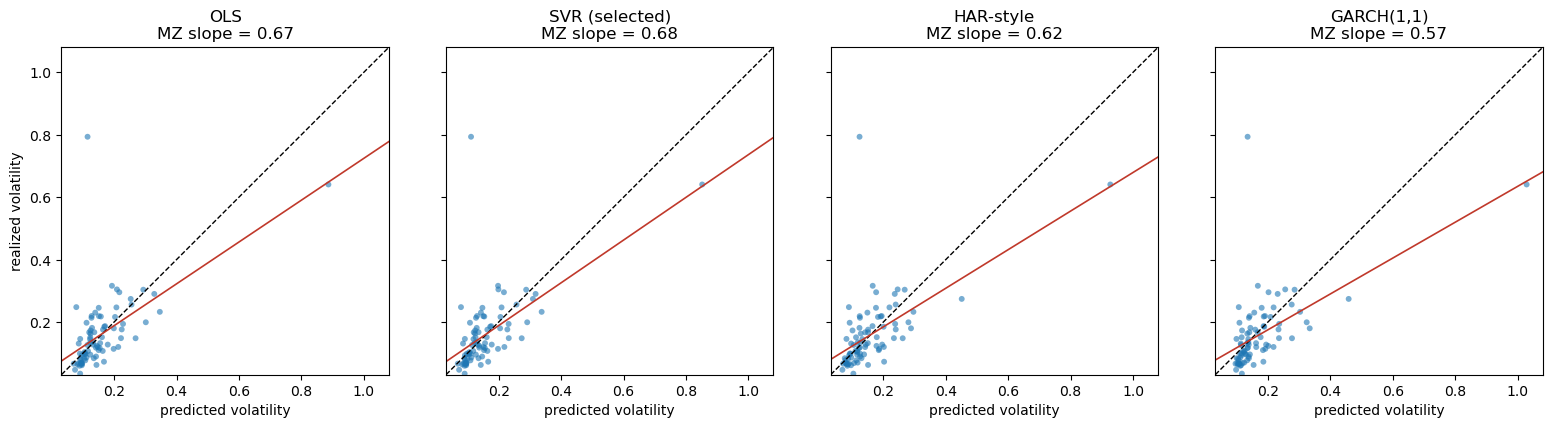

In [47]:
names = [m for m in models if m != 'Naive']
fig, axes = plt.subplots(1, len(names), figsize=(4*len(names), 4),
                         sharex=True, sharey=True)

lo = min(actual.min(), min(models[n].min() for n in names)) * 0.9
hi = max(actual.max(), max(models[n].max() for n in names)) * 1.05

for ax, name in zip(np.atleast_1d(axes), names):
    pred = models[name]
    ax.scatter(pred, actual, s=18, alpha=0.6, edgecolor='none')
    ax.plot([lo, hi], [lo, hi], 'k--', lw=1)          # perfect forecast

    b, a = np.polyfit(pred, actual, 1)                 # Mincer-Zarnowitz slope
    ax.plot([lo, hi], [a + b*lo, a + b*hi], color='#c0392b', lw=1.2)

    ax.set_title(f'{name}\nMZ slope = {b:.2f}')
    ax.set_xlabel('predicted volatility')
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ax.set_aspect('equal')

np.atleast_1d(axes)[0].set_ylabel('realized volatility')
plt.tight_layout()

Each point is one 21-day volatility forecast.

**Dashed line** = perfect forecast 

**red line** = Mincer-Zarnowitz regression of the realized volatility on the forecast, $RV_t = a + b\,\hat\sigma_t$. An unbiased, correctly scaled forecast gives $a=0$ and $b=1$; $b<1$ means the model over-reacts, $b>1$ that it under-reacts. (Regressing in the other direction, forecast on realized, would give a slope below 1 even for a perfect conditional expectation, so the direction matters.)

#### Covid Effect
As shown in the graph above, the points furthest from the diagonal correspond to feb-jun 2020, during the **Covid pandemic**. 
These few observations dominate the squared-error metrics (MSE, RMSE, R²); QLIKE, which is scale-free, is much less affected by them, which is why it is used as the primary metric.

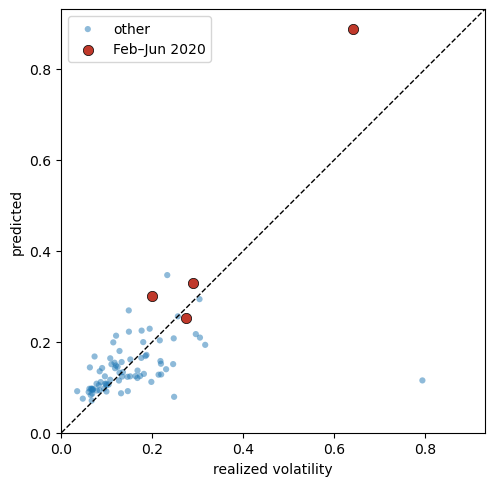

In [49]:
covid = (actual.index >= '2020-02-15') & (actual.index <= '2020-06-30')

fig, ax = plt.subplots(figsize=(5.5, 5.5))
pred = models['OLS']

ax.scatter(actual[~covid], pred[~covid], s=20, alpha=0.5,
           edgecolor='none', label='other')
ax.scatter(actual[covid], pred[covid], s=55, color='#c0392b',
           edgecolor='black', linewidth=0.5, zorder=3, label='Feb–Jun 2020')

lo, hi = 0, max(actual.max(), pred.max())*1.05
ax.plot([lo, hi], [lo, hi], 'k--', lw=1)
ax.set_xlim(lo, hi); ax.set_ylim(lo, hi); ax.set_aspect('equal')
ax.set_xlabel('realized volatility'); ax.set_ylabel('predicted')
ax.legend()